# Project 2: Joint Detection of AI-Generated Images & Post-Processing Alterations

Single notebook for the whole project, following the required section structure:
**Imports · Globals · Utils · Data · Network · Train · Evaluation**.

The **Data** section below is the data pipeline: find the dataset, build a table that
describes every image, pick a balanced subset, check the balance, and split the data so
that no scene leaks between train and test.

**The dataset.** We use the `RRDataset_test` tar. After it is unpacked the folders look like:

```
original/   {ai, real}     # clean images
transfer/   {ai, real}     # internet-transmitted (social-media compression)
redigital/  {ai, real}     # re-digitized (printed then scanned / re-photographed)
```

The **same scene** appears once in each of the three transform folders. That is convenient,
but it is also a trap: if we split images randomly, the *original* of a scene could land in
the training set while its *transmitted* copy lands in the test set: the model would then be
tested on content it already saw. We avoid this by giving every scene an id (`base_id`) and
keeping all three copies of a scene in the same split.

> **Setup:** just paste the dataset folder path into `DATA_ROOT` in the **Globals** section
> below. (If your data is still a `.tar`, there is a one-line optional cell to unpack it.)

> **Note.** This tar does not tell us *which* of the 4 re-digitization methods (scan,
> photo of print, photo of screen, photo of projection) produced each `redigital` image, so
> the transformation task stays 3-class: original / transmitted / re-digitized.

## Imports

In [1]:
# %pip install -q numpy pandas matplotlib seaborn scikit-learn Pillow torch

In [2]:
# --- standard library ---
import os
import re
import random
from pathlib import Path

# --- data handling & plotting ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- machine learning ---
import torch
from PIL import Image
from sklearn.model_selection import train_test_split

## Globals
Every setting you might want to change lives here, so you never have to hunt for it.

In [3]:
# Reproducibility.
SEED = 42

# ---------------------------------------------------------------------------
# Dataset Path.
DATA_ROOT = "/kaggle/input/datasets/jannip/rrdataset/RRDataset_final"

# ---------------------------------------------------------------------------
# FOLDER NAMES TO LABELS
# Task A (authenticity): is the image real or AI-generated?
REALFAKE_ID   = {"real": 0, "ai": 1}     # the number the model will predict
REALFAKE_NAME = {0: "real", 1: "fake"}   # a readable name for plots/tables

# Task B (transformation): what post-processing was applied?
TRANSFORM_FOLDERS = ["original", "transfer", "redigital"]   # the folder names on disk
TRANSFORM_ID      = {"original": 0, "transfer": 1, "redigital": 2}
TRANSFORM_NAME    = {"original": "original", "transfer": "transmitted", "redigital": "redigitized"}

CLASS_FOLDERS = ["real", "ai"]
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".webp", ".bmp"}

# ---------------------------------------------------------------------------
# HOW MUCH DATA TO USE, AND HOW TO SPLIT IT
# Number of scenes PER CLASS to keep. Each scene = 3 images (one per transform).
SUBSET_PER_CLASS = 8000
SPLIT_RATIOS = (0.70, 0.15, 0.15)   # train / validation / test, measured in scenes

# Where to save outputs.
OUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")
INDEX_CSV = OUT_DIR / "rrdataset_index.csv"

## Utils
Small helper functions used by the Data section below.

**Make the run reproducible** by seeding every random number generator.

In [4]:
def set_seed(seed):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

**Check the hardware.** On Kaggle, switch the accelerator to GPU in the settings panel.

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0), "| CUDA", torch.version.cuda)

Using device: cpu


**Read the labels from the file name.**
The three copies of one scene share a name except for a `transfer_` / `redigital_` prefix and
the extension. Stripping those gives a single id that links them.

In [6]:
def get_base_id(filename):
    """Turn a file name into a scene id shared by its 3 transform versions.

        Culture_&_Religion_000001.png            -> Culture_&_Religion_000001
        transfer_Culture_&_Religion_000001.jpg   -> Culture_&_Religion_000001
        redigital_real_000001.jpg                -> real_000001
    """
    name_without_extension = os.path.splitext(filename)[0]
    return re.sub(r"^(transfer_|redigital_)", "", name_without_extension)


def get_scenario(base_id, is_fake):
    """AI file names start with a scenario (e.g. 'War_&_Conflict_Scenes_000012').
    Real images are just 'real_000012', so we label them all 'real'."""
    if not is_fake:
        return "real"
    return re.sub(r"_\d+$", "", base_id)   # drop the trailing number

**A small plotting helper** that draws a labelled bar chart of category counts.

In [7]:
def bar_counts(values, title, ax):
    counts = values.value_counts().sort_index()
    sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax)
    ax.set_title(title)
    ax.set_ylabel("number of images")
    for i, n in enumerate(counts.values):
        ax.text(i, n, str(n), ha="center", va="bottom", fontsize=9)

## Data

### 1. Check the dataset folder and look at its structure
We make sure `DATA_ROOT` really contains the three transform folders, then count the images in
each of the 6 folders so we know everything is where we expect before going further.

In [8]:
DATA_ROOT = Path(DATA_ROOT)
assert DATA_ROOT.exists(), f"DATA_ROOT does not exist: {DATA_ROOT}\nFix the path in Globals."
for transform in TRANSFORM_FOLDERS:
    assert (DATA_ROOT / transform).is_dir(), f"Missing '{transform}' folder inside {DATA_ROOT}"
print("Dataset folder looks good:", DATA_ROOT, "\n")

print("Images found in each folder:")
for transform in TRANSFORM_FOLDERS:
    for image_class in CLASS_FOLDERS:
        folder = DATA_ROOT / transform / image_class
        n_images = sum(1 for f in folder.iterdir() if f.suffix.lower() in IMAGE_EXTENSIONS)
        print(f"  {transform:10s} / {image_class:4s} : {n_images:6d}")

Dataset folder looks good: /kaggle/input/datasets/jannip/rrdataset/RRDataset_final 

Images found in each folder:
  original   / real :   8500
  original   / ai   :   8500
  transfer   / real :   8500
  transfer   / ai   :   8500
  redigital  / real :   8499
  redigital  / ai   :   8500


### 2. Build a table describing every image
Instead of juggling file paths, we put everything into one pandas table (one row per image).
Each row stores the path, the two labels, the scene id, and the scenario.

In [9]:
records = []
for transform in TRANSFORM_FOLDERS:          # original / transfer / redigital
    for image_class in CLASS_FOLDERS:        # real / ai
        folder = Path(DATA_ROOT) / transform / image_class
        is_fake = REALFAKE_ID[image_class]   # 0 = real, 1 = fake

        for image_path in folder.iterdir():
            if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
                continue                     # ignore anything that is not an image
            base_id = get_base_id(image_path.name)
            records.append({
                "path":           str(image_path),
                "realfake":       is_fake,
                "realfake_name":  REALFAKE_NAME[is_fake],
                "transform":      TRANSFORM_ID[transform],
                "transform_name": TRANSFORM_NAME[transform],
                # prefix the id with the class so a real scene and an ai scene never clash
                "base_id":        f"{image_class}/{base_id}",
                "scenario":       get_scenario(base_id, is_fake),
            })

df = pd.DataFrame(records)
print(f"Indexed {len(df)} images belonging to {df.base_id.nunique()} different scenes.")
df.head()

Indexed 50999 images belonging to 17000 different scenes.


,path,realfake,realfake_name,transform,transform_name,base_id,scenario
0,/kaggle/input/datasets/jannip/rrdataset/RRData...,0,real,0,original,real/real_002233,real
1,/kaggle/input/datasets/jannip/rrdataset/RRData...,0,real,0,original,real/real_000837,real
2,/kaggle/input/datasets/jannip/rrdataset/RRData...,0,real,0,original,real/real_005864,real
3,/kaggle/input/datasets/jannip/rrdataset/RRData...,0,real,0,original,real/real_008690,real
4,/kaggle/input/datasets/jannip/rrdataset/RRData...,0,real,0,original,real/real_009458,real


In [10]:
# Quick look: how many images are in each (transform x class) combination?
pd.crosstab(df.transform_name, df.realfake_name)

realfake_name,fake,real
transform_name,,
original,8500,8500
redigitized,8500,8499
transmitted,8500,8500


### 3. Pick a balanced subset (by scene)
We only keep scenes that have all three transform versions, then take the same number of
scenes from each class. Because each scene contributes exactly 3 images, the six groups end
up balanced automatically.

In [11]:
# Each scene should appear 3 times (once per transform). Keep the complete ones only.
images_per_scene = df["base_id"].value_counts()
complete_scenes = images_per_scene[images_per_scene == 3].index
df = df[df["base_id"].isin(complete_scenes)].copy()
print("Scenes with all 3 versions:", len(complete_scenes))

# Make a small table with one row per scene (its id + whether it is real or fake).
scenes = df.drop_duplicates("base_id")[["base_id", "realfake"]]

# Split that into real scenes and fake scenes.
real_scenes = scenes[scenes["realfake"] == 0]["base_id"].tolist()
fake_scenes = scenes[scenes["realfake"] == 1]["base_id"].tolist()

# Shuffle each list, then keep the same number of scenes from each class.
random.Random(SEED).shuffle(real_scenes)
random.Random(SEED).shuffle(fake_scenes)
if SUBSET_PER_CLASS is not None:
    real_scenes = real_scenes[:SUBSET_PER_CLASS]
    fake_scenes = fake_scenes[:SUBSET_PER_CLASS]

chosen_scenes = real_scenes + fake_scenes
subset = df[df["base_id"].isin(chosen_scenes)].reset_index(drop=True)
print(f"Kept {len(chosen_scenes)} scenes  ->  {len(subset)} images")
pd.crosstab(subset["transform_name"], subset["realfake_name"])

Scenes with all 3 versions: 16999
Kept 16000 scenes  ->  48000 images


realfake_name,fake,real
transform_name,,
original,8000,8000
redigitized,8000,8000
transmitted,8000,8000


### 4. Check the class balance
The brief asks us to confirm the data is balanced before training. A quick bar chart per label
is the clearest way to show it.

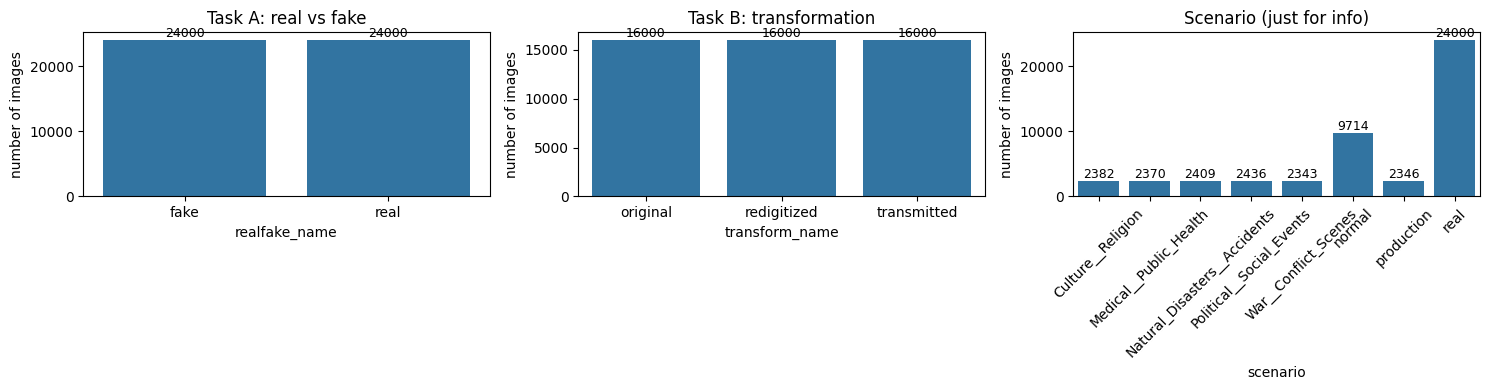

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
bar_counts(subset.realfake_name,  "Task A: real vs fake",       axes[0])
bar_counts(subset.transform_name, "Task B: transformation",     axes[1])
bar_counts(subset.scenario,       "Scenario (just for info)",   axes[2])
axes[2].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### 5. Split into train / validation / test, by scene
We split the *scenes*, not the images, so that all three versions of a scene stay together.
We do it in two steps: first peel off the training scenes, then divide the rest into
validation and test. `stratify` keeps the real/fake ratio steady in every split.

In [13]:
# One row per scene again, so we split scenes (not images): all 3 copies stay together.
scenes = subset.drop_duplicates("base_id")[["base_id", "realfake"]]
train_ratio, val_ratio, test_ratio = SPLIT_RATIOS

# Step 1: take out the training scenes. "temp" holds validation + test for now.
train_scenes, temp_scenes = train_test_split(
    scenes,
    test_size=val_ratio + test_ratio,          # e.g. 0.30 -> goes to val + test
    stratify=scenes["realfake"],               # keep real/fake balanced
    random_state=SEED,
)

# Step 2: cut "temp" in half into validation and test.
val_scenes, test_scenes = train_test_split(
    temp_scenes,
    test_size=test_ratio / (val_ratio + test_ratio),   # half of temp -> test
    stratify=temp_scenes["realfake"],
    random_state=SEED,
)

# Give every image the split that its scene landed in.
val_ids  = set(val_scenes["base_id"])
test_ids = set(test_scenes["base_id"])
subset["split"] = "train"                                      # everyone starts as train
subset.loc[subset["base_id"].isin(val_ids),  "split"] = "val"
subset.loc[subset["base_id"].isin(test_ids), "split"] = "test"

print(subset["split"].value_counts(), "\n")
print("Real/fake share inside each split (should stay ~50/50):")
print(pd.crosstab(subset["split"], subset["realfake_name"], normalize="index").round(3))

split
train    33600
test      7200
val       7200
Name: count, dtype: int64 

Real/fake share inside each split (should stay ~50/50):
realfake_name  fake  real
split                    
test            0.5   0.5
train           0.5   0.5
val             0.5   0.5


### 6. Prove there is no leakage
This is the most important correctness check: a scene must live in exactly one split. If any
scene appears in two splits, one of these asserts will stop the notebook.

In [14]:
train_ids = set(subset[subset.split == "train"].base_id)
val_ids   = set(subset[subset.split == "val"].base_id)
test_ids  = set(subset[subset.split == "test"].base_id)

assert train_ids.isdisjoint(val_ids),  "Leak: a scene is in both train and val!"
assert train_ids.isdisjoint(test_ids), "Leak: a scene is in both train and test!"
assert val_ids.isdisjoint(test_ids),   "Leak: a scene is in both val and test!"

print("No leakage: every scene is in exactly one split.")
print(f"  train: {len(train_ids)} scenes | val: {len(val_ids)} | test: {len(test_ids)}")

No leakage: every scene is in exactly one split.
  train: 11200 scenes | val: 2400 | test: 2400


### 7. Save the table
Later sections (and reruns) just load this CSV instead of scanning the folders again.

In [15]:
subset.to_csv(INDEX_CSV, index=False)
print("Saved the image table to:", INDEX_CSV.resolve())
subset.head()

Saved the image table to: /kaggle/working/rrdataset_index.csv


,path,realfake,realfake_name,transform,transform_name,base_id,scenario,split
0,/kaggle/input/datasets/jannip/rrdataset/RRData...,0,real,0,original,real/real_002233,real,train
1,/kaggle/input/datasets/jannip/rrdataset/RRData...,0,real,0,original,real/real_000837,real,test
2,/kaggle/input/datasets/jannip/rrdataset/RRData...,0,real,0,original,real/real_005864,real,test
3,/kaggle/input/datasets/jannip/rrdataset/RRData...,0,real,0,original,real/real_009458,real,val
4,/kaggle/input/datasets/jannip/rrdataset/RRData...,0,real,0,original,real/real_004735,real,test


## Network
_Frozen DINOv3 backbone → shared trainable trunk → two task heads (real/fake + transformation). To be implemented._

## Train
_Feature caching, unimodal baselines, and joint multi-task training with the loss-weight sweep. To be implemented._

## Evaluation
_Per-task metrics, confusion matrices, per-transformation breakdown, and the loss-weight ablation. To be implemented._